In [68]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import math

In [69]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [70]:
df = pd.DataFrame(X, columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.554271,-0.062734,1.985899,-3.102844,-2.145204,1
1,0.911388,-0.113118,0.597435,1.207380,-3.446239,0
2,1.755059,-0.704405,-0.028300,-0.094310,-2.464614,0
3,-3.576592,-1.601226,1.798966,2.024744,1.141007,0
4,-0.333261,-0.872877,1.414186,1.648148,-2.763609,0


In [71]:
# function for row sampling

def sample_rows(df, percent):
    return df.sample(int(percent*df.shape[0]), replace=True)

In [90]:
# function for columns sampling
import random

def sample_features(df, percent):
    feature_cols = df.columns[:-1].tolist()

    k = int(percent * len(feature_cols))
    cols = random.sample(feature_cols, k)
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df

In [94]:
# function combined sampling

def combined_sampling(df, row_percent, col_percent):
    new_df = sample_rows(df, row_percent)
    return sample_features(new_df, col_percent)

In [95]:
df1 = sample_features(df, 0.8)

C:\Users\HP\AppData\Local\Temp\ipykernel_1208\749806466.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [96]:
df2 = sample_features(df, 0.8)

C:\Users\HP\AppData\Local\Temp\ipykernel_1208\749806466.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [97]:
df3 = sample_features(df, 0.8)

C:\Users\HP\AppData\Local\Temp\ipykernel_1208\749806466.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [103]:
from sklearn.tree import DecisionTreeClassifier

clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [104]:
clf1.fit(df1.iloc[:, 0:4], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, 0:4], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, 0:4], df3.iloc[:, -1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [105]:
from sklearn.tree import plot_tree

[Text(0.4880952380952381, 0.9166666666666666, 'x[1] <= 0.386\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.21428571428571427, 0.75, 'x[0] <= -0.744\ngini = 0.302\nsamples = 54\nvalue = [44, 10]'),
 Text(0.35119047619047616, 0.8333333333333333, 'True  '),
 Text(0.09523809523809523, 0.5833333333333334, 'x[3] <= 0.668\ngini = 0.473\nsamples = 13\nvalue = [5, 8]'),
 Text(0.047619047619047616, 0.4166666666666667, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.14285714285714285, 0.4166666666666667, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.3333333333333333, 0.5833333333333334, 'x[2] <= -3.538\ngini = 0.093\nsamples = 41\nvalue = [39, 2]'),
 Text(0.23809523809523808, 0.4166666666666667, 'x[1] <= -0.96\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.19047619047619047, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2857142857142857, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.42857142857142855, 0.4166666666666667, 'x[3] <= -2.309\ngini = 0.0

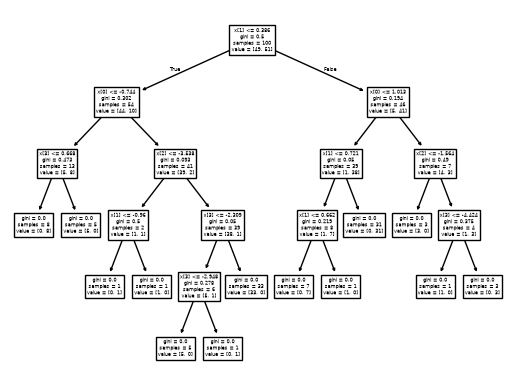

In [106]:
plot_tree(clf1)

[Text(0.4583333333333333, 0.9375, 'x[1] <= 0.326\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.25, 0.8125, 'x[2] <= 1.613\ngini = 0.357\nsamples = 56\nvalue = [13, 43]'),
 Text(0.35416666666666663, 0.875, 'True  '),
 Text(0.16666666666666666, 0.6875, 'x[0] <= -0.257\ngini = 0.187\nsamples = 48\nvalue = [5, 43]'),
 Text(0.08333333333333333, 0.5625, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.25, 0.5625, 'x[0] <= 0.683\ngini = 0.122\nsamples = 46\nvalue = [3, 43]'),
 Text(0.16666666666666666, 0.4375, 'x[2] <= -1.109\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.08333333333333333, 0.3125, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.25, 0.3125, 'x[1] <= -1.167\ngini = 0.5\nsamples = 6\nvalue = [3, 3]'),
 Text(0.16666666666666666, 0.1875, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.3333333333333333, 0.1875, 'x[0] <= -0.097\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.25, 0.0625, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4166666666

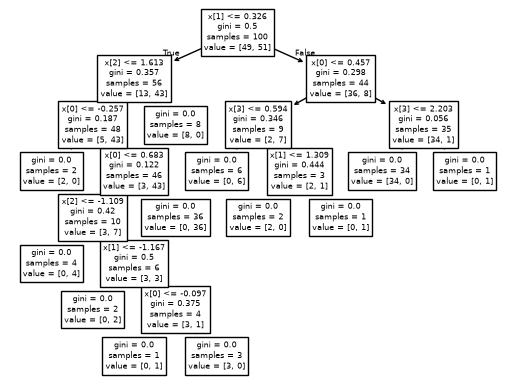

In [107]:
plot_tree(clf2)

[Text(0.4583333333333333, 0.9375, 'x[3] <= 0.326\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.25, 0.8125, 'x[0] <= 1.613\ngini = 0.357\nsamples = 56\nvalue = [13, 43]'),
 Text(0.35416666666666663, 0.875, 'True  '),
 Text(0.16666666666666666, 0.6875, 'x[2] <= -0.257\ngini = 0.187\nsamples = 48\nvalue = [5, 43]'),
 Text(0.08333333333333333, 0.5625, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.25, 0.5625, 'x[2] <= 0.683\ngini = 0.122\nsamples = 46\nvalue = [3, 43]'),
 Text(0.16666666666666666, 0.4375, 'x[0] <= -1.109\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.08333333333333333, 0.3125, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.25, 0.3125, 'x[3] <= -1.167\ngini = 0.5\nsamples = 6\nvalue = [3, 3]'),
 Text(0.16666666666666666, 0.1875, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.3333333333333333, 0.1875, 'x[2] <= -0.097\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.25, 0.0625, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4166666666

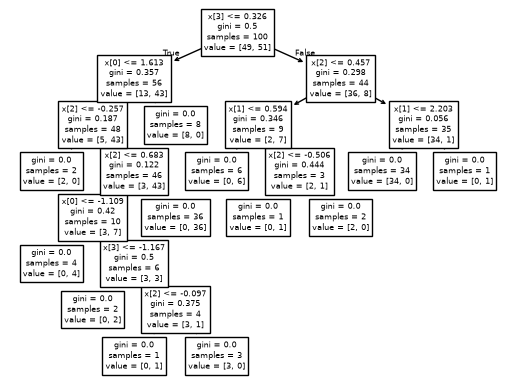

In [108]:
plot_tree(clf3)

In [109]:
df3

,col1,col5,col3,col4,target
0,-0.554271,-2.145204,1.985899,-3.102844,1
1,0.911388,-3.446239,0.597435,1.207380,0
2,1.755059,-2.464614,-0.028300,-0.094310,0
3,-3.576592,1.141007,1.798966,2.024744,0
4,-0.333261,-2.763609,1.414186,1.648148,0
...,...,...,...,...,...
95,-0.194395,-1.847361,0.674380,0.995585,0
96,1.471346,-3.785820,2.807994,-3.571793,1
97,0.056951,-0.483064,1.173929,0.412940,0
98,-0.951472,-1.719992,1.333053,1.410731,0


In [110]:
clf1.predict(np.array([-0.554271,	-2.145204,	1.985899,	-3.102844]).reshape(1,4))

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [111]:
clf2.predict(np.array([-0.554271,	-2.145204,	1.985899,	-3.102844]).reshape(1,4))

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [112]:
clf3.predict(np.array([-0.554271,	-2.145204,	1.985899,	-3.102844]).reshape(1,4))

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])